In [6]:
import time
import random
import numpy as np
np.set_printoptions(suppress=True, precision=6)

import matplotlib.pyplot as plt
from scipy.special import erf

import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')
from aare import fit_scurve, fit_scurve2, fit_scurve_minuit_grad, fit_scurve2_minuit_grad
from aare import RisingScurve, FallingScurve, fit # object based API

from pprint import pprint

## Model curves

In [7]:
def scurve(x, p): # rising Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 + erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

def scurve2(x, p): #falling Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 - erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

## Generate data (1D)

In [8]:
x = np.linspace(0,120, 121)

rng = np.random.default_rng(42)
0
p_true_rising = np.array([100.0, 0.25, 60.0, 6.0, 120.0,  1.0])
p_true_falling = np.array([100.0, 0.25, 60.0, 6.0, 120.0, -1.0])

y_true_rising = scurve(x, p_true_rising)
y_true_falling = scurve2(x, p_true_falling)

noise_sigma = 4

y_rising = y_true_rising + rng.normal(0, noise_sigma, size=x.shape)
# y_err_r = np.full_like(x, noise_sigma)

y_falling = y_true_falling + rng.normal(0, noise_sigma, size=x.shape)
# y_err_f = np.full_like(x, noise_sigma)

## Plot synthetic data

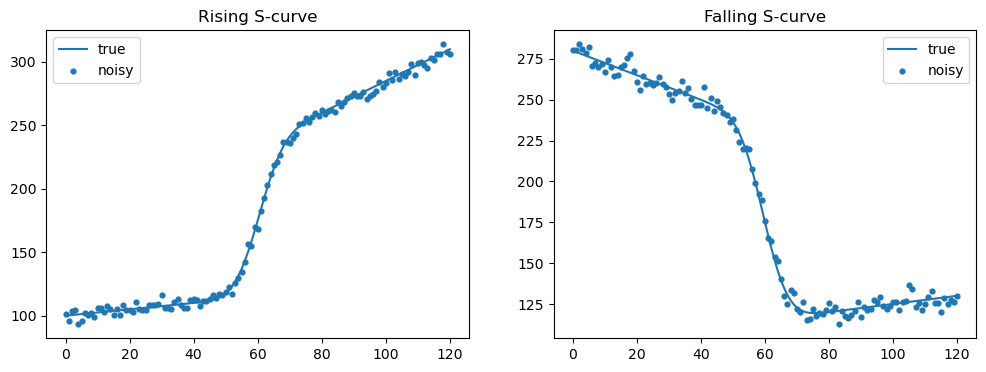

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharex=True)

ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="noisy")
ax[0].set_title("Rising S-curve")
ax[0].legend()

ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="noisy")
ax[1].set_title("Falling S-curve")
ax[1].legend()

plt.show()

## Fit the Rising S-curve

In [14]:
res_r_lmfit = fit_scurve(x, y_rising)
res_r_minuit_grad = fit_scurve_minuit_grad(x, y_rising, np.sqrt(y_rising))

model_r = RisingScurve()
# model_r.FixParameter(0, 100)  # Fixed p0 = 100 (optimizer does not touch the value)
# model_r.SetStartValue(4, 100) # Start value p4 = 100 
print("== Tuned fit settings ==")
model_r.compute_errors = True
model_r.max_calls = 500
model_r.tolerance = 0.01
print(f"max_calls : {model_r.max_calls}")
print(f"tolerance : {model_r.tolerance}")
print(f"compute_erros: {model_r.compute_errors}")
print("\n")
print("== Results ==")
res_r_munuit_obj = fit(model_r, x, y_rising, np.sqrt(y_rising))

print("True rising params:         ", p_true_rising)
print("lmfit rising result:        ", res_r_lmfit)
print("minuit_grad (fct call) rising result:  \n", res_r_minuit_grad)
print("minuit_grad (obj api ) rising result:")
pprint(res_r_munuit_obj, sort_dicts=False)

== Tuned fit settings ==
max_calls : 500
tolerance : 0.01
compute_erros: True


== Results ==
True rising params:          [100.     0.25  60.     6.   120.     1.  ]
lmfit rising result:         [ 99.467831   0.287017  60.078405   5.715461 117.257939   0.967234]
minuit_grad (fct call) rising result:  
 [ 99.30702    0.290964  60.093369   5.684156 117.168201   0.963449
   2.853966   0.104678   0.765079   0.930833   8.317105   0.191755
   7.289885]
minuit_grad (obj api ) rising result:
{'par': array([ 99.287814,   0.291561,  60.091183,   5.675717, 117.086072,
         0.963849]),
 'par_err': array([2.85386 , 0.104652, 0.764938, 0.930069, 8.309706, 0.191749]),
 'chi2': array([7.289656])}


## Fit the Falling S-curve

In [21]:
res_f_lmfit = fit_scurve2(x, y_falling)
res_f_minuit_grad = fit_scurve2_minuit_grad(x, y_falling)

model_f = FallingScurve()
model_f.SetStartValue(2, 20) # set start p2 = 20
model_f.SetStartValue(4, 90) # set start p4 = 90
model_f.SetParLimits(4, 80, 130)
model_f.max_calls = 150 # this is limits the number of calls done by the minimizer (increasing the `max_calls` may help if the fit fails) 
res_f_munuit_obj = fit(model_f, x, y_falling)

print("True falling params:  ", p_true_falling)
print("lmfit falling result:  ", res_f_lmfit)
print("minuit_grad (fct call) falling result:  \n", res_f_minuit_grad)
print("minuit_grad (obj api ) falling result")
pprint(res_f_munuit_obj, sort_dicts=False)

True falling params:   [100.     0.25  60.     6.   120.    -1.  ]
lmfit falling result:   [101.734479   0.225786  60.251971   6.092915 118.476735  -0.998677]
minuit_grad (fct call) falling result:  
 [ 101.735619    0.225778   60.251958    6.09264   118.475651   -0.998681
 1865.728741]
minuit_grad (obj api ) falling result
{'par': array([101.734403,   0.225778,  60.251667,   6.093245, 118.479457,
        -0.998603]),
 'chi2': array([1865.728851])}


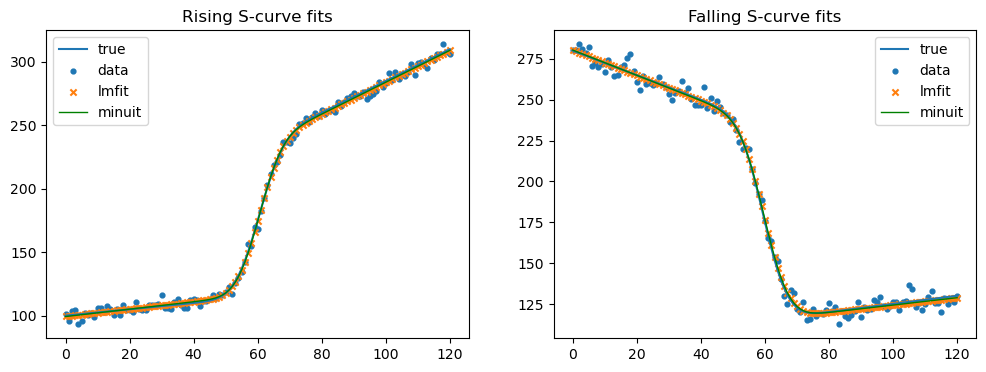

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# rising
ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="data")
ax[0].scatter(x, scurve(x, res_r_lmfit[:6]), s=20, marker="x", label="lmfit")
# ax[0].plot(x, scurve(x, res_r_minuit_grad[:6]), linewidth=1, color="green", label="minuit")
ax[0].plot(x, scurve(x, res_r_munuit_obj['par']), linewidth=1, color="green", label="minuit")
ax[0].set_title("Rising S-curve fits")
ax[0].legend()

# falling
ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="data")
ax[1].scatter(x, scurve2(x, res_f_lmfit[:6]), s=20, marker="x", label="lmfit")
# ax[1].plot(x, scurve2(x, res_f_minuit_grad[:6]), linewidth=1, color="green", label="minuit")
ax[1].plot(x, scurve2(x, res_f_munuit_obj['par']), linewidth=1, color="green", label="minuit")
ax[1].set_title("Falling S-curve fits")
ax[1].legend()

plt.show()

## Quick error check

In [23]:
print("Rising abs error lmfit : ", np.abs(res_r_lmfit[:6] - p_true_rising))
# print("Rising abs error minuit_grad: ", np.abs(res_r_minuit_grad[:6] - p_true_rising))
print("Rising abs error minuit_grad: ", np.abs(res_r_munuit_obj['par'] - p_true_rising))
print("\n")
print("Falling abs error lmfit : ", np.abs(res_f_lmfit[:6] - p_true_falling))
# print("Falling abs error minuit_grad: ", np.abs(res_f_minuit_grad[:6] - p_true_falling))
print("Falling abs error minuit_grad: ", np.abs(res_f_munuit_obj['par'] - p_true_falling))

Rising abs error lmfit :  [0.532169 0.037017 0.078405 0.284539 2.742061 0.032766]
Rising abs error minuit_grad:  [0.712186 0.041561 0.091183 0.324283 2.913928 0.036151]


Falling abs error lmfit :  [1.734479 0.024214 0.251971 0.092915 1.523265 0.001323]
Falling abs error minuit_grad:  [1.734403 0.024222 0.251667 0.093245 1.520543 0.001397]


## Benchmark

In [24]:
def bench(fn, n_repeats=200):
    # warmup
    for _ in range(3):
        fn()

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        res = fn()
    t1 = time.perf_counter()
    return res, (t1 - t0) / n_repeats

model_rising  = RisingScurve()
model_falling = FallingScurve()

res_r_lmfit,  t_r_lmfit       = bench(lambda: fit_scurve(x, y_rising))
res_r_minuit, t_r_minuit_grad = bench(lambda: fit_scurve_minuit_grad(x, y_rising))
res_r_new,    t_r_new         = bench(lambda: fit(model_rising, x, y_rising))

res_f_lmfit,  t_f_lmfit       = bench(lambda: fit_scurve2(x, y_falling))
res_f_minuit, t_f_minuit_grad = bench(lambda: fit_scurve2_minuit_grad(x, y_falling))
res_f_new,    t_f_new         = bench(lambda: fit(model_falling, x, y_falling))

print(f"Rising  lmfit       : {1e3*t_r_lmfit:.3f} ms")
print(f"Rising  minuit_grad : {1e3*t_r_minuit_grad:.3f} ms")
print(f"Rising  fit(model)  : {1e3*t_r_new:.3f} ms")
print()
print(f"Falling lmfit       : {1e3*t_f_lmfit:.3f} ms")
print(f"Falling minuit_grad : {1e3*t_f_minuit_grad:.3f} ms")
print(f"Falling fit(model)  : {1e3*t_f_new:.3f} ms")

Rising  lmfit       : 0.484 ms
Rising  minuit_grad : 0.309 ms
Rising  fit(model)  : 0.299 ms

Falling lmfit       : 0.373 ms
Falling minuit_grad : 0.296 ms
Falling fit(model)  : 0.292 ms
